In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [62]:
std = pd.read_csv('../dataset/lab3/std_awareness_res.csv')
print(std.head());

           Timestamp  Registration Number  \
0  6/15/2026 9:25:39              2547231   
1  6/15/2026 9:53:54              2547237   
2  6/15/2026 9:54:56              2547203   
3  6/15/2026 9:55:17              2547228   
4  6/15/2026 9:55:42              2547241   

                                        Email  \
0       kunnal.kunnal@mca.christuniversity.in   
1  omkaar.chakraborty@mca.christuniversity.in   
2        abhinav.jain@mca.christuniversity.in   
3          jai.pareek@mca.christuniversity.in   
4             r.karan@mca.christuniversity.in   

   Job role that you are interested in  \
0  Software Development Engineer (SDE)   
1  Software Development Engineer (SDE)   
2                 Full Stack Developer   
3                 Full Stack Developer   
4  Software Development Engineer (SDE)   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0                                                3.5                                 

In [63]:
print(std.shape)

(50, 15)


In [64]:
print(std.dtypes)

Timestamp                                                                                      object
Registration Number                                                                             int64
Email                                                                                          object
Job role that you are interested in                                                            object
What is the minimum salary of students placed through campus (In LPA..respond as a number)     object
What is the maximum salary of students placed through campus (In LPA..respond as a number)     object
What is the median salary of students placed through campus (In LPA..respond as a number)      object
Which is the highest paying company that recruits from campus?                                 object
Rate your contribution towards extra curricular activities                                    float64
Rate your technical competencies                                                  

In [65]:
# covert to numeric
cols = [
    'Your CIA % of last semester',
    'Your GPA of last semester',
    'Your maximum attendance % till last semester'
]

for col in cols:
    std[col] = pd.to_numeric(std[col], errors='coerce')

In [66]:
#missing values
print(std[cols].isnull().sum())

Your CIA % of last semester                     10
Your GPA of last semester                        0
Your maximum attendance % till last semester    10
dtype: int64


In [67]:
#remove null
std = std.dropna(subset=cols)

In [68]:
#remove duplicates
std = std.drop_duplicates()

In [69]:
print(std[cols].describe())

       Your CIA % of last semester  Your GPA of last semester  \
count                    39.000000                  39.000000   
mean                     72.546667                   3.418974   
std                       5.968592                   0.207413   
min                      60.000000                   3.000000   
25%                      69.890000                   3.325000   
50%                      71.780000                   3.400000   
75%                      75.600000                   3.575000   
max                      91.000000                   3.790000   

       Your maximum attendance % till last semester  
count                                     39.000000  
mean                                      94.218974  
std                                        3.778685  
min                                       85.000000  
25%                                       92.500000  
50%                                       95.000000  
75%                                 

## Experiment 1
CIA → GPA

In [70]:
# Independent Variable
X = std[['Your CIA % of last semester']]
# Dependent Variable
y = std['Your GPA of last semester']

In [71]:
# Train-Test Split
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [72]:
# Train Model

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [73]:
import pickle

cia_model_params = {
    "slope": model.coef_[0],
    "intercept": model.intercept_
}

with open("cia_model.pkl", "wb") as f:
    pickle.dump(cia_model_params, f)

print("CIA model saved successfully")

CIA model saved successfully


In [74]:
# Slope and Intercept

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.01652616755411488
Intercept: 2.2121674902659114


In [75]:
# Predictions

y_pred = model.predict(X_test)
print(y_pred)

[3.45493529 3.45163006 3.36899922 3.36899922 3.31942072 3.53426089
 3.43510389 3.36899922]


In [76]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -----------------------------
# R² Score
# -----------------------------

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

# -----------------------------
# MSE (Mean Squared Error)
# -----------------------------
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# -----------------------------
# RMSE (Root Mean Squared Error)
# -----------------------------
rmse = mse ** 0.5
print("RMSE:", rmse)

# -----------------------------
# RSE (Residual Standard Error)
# -----------------------------
import numpy as np

n = len(y_test)          # number of test samples
p = 1                    # simple linear regression

rse = np.sqrt(mse * (n / (n - p - 1)))
print("RSE:", rse)

R² Score: -0.638004118284407
MSE: 0.03601305616934358
RMSE: 0.18977106251835021
RSE: 0.21912874805874158


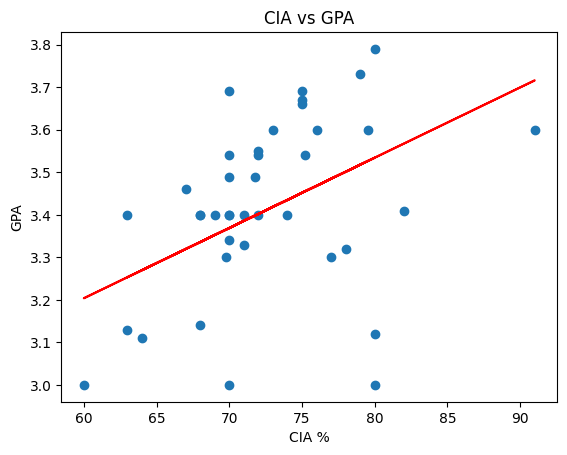

In [77]:
# Plot

plt.scatter(
    X,
    y
)

plt.plot(
    X,
    model.predict(X),
    color='red'
)

plt.xlabel('CIA %')
plt.ylabel('GPA')
plt.title('CIA vs GPA')
plt.show()


In [78]:
# Manual OLS

x = std['Your CIA % of last semester']
y = std['Your GPA of last semester']

n = len(std)

sum_x = x.sum()
sum_y = y.sum()
sum_xy = (x*y).sum()
sum_x2 = (x**2).sum()

m = ((n*sum_xy)-(sum_x*sum_y))/((n*sum_x2)-(sum_x**2))
c = (sum_y-(m*sum_x))/n

print("Slope:",m)
print("Intercept:",c)

Slope: 0.013568336270762081
Intercept: 2.4346367903181396


In [79]:
# manual prediction
manual_pred = m * X_test.iloc[:,0] + c
print(manual_pred)

41    3.454976
45    3.452262
4     3.384420
14    3.384420
37    3.343715
31    3.520104
6     3.438694
33    3.384420
Name: Your CIA % of last semester, dtype: float64


In [80]:
# Compare Both
comparison = pd.DataFrame({
    'Scikit Learn': y_pred,
    'Manual OLS': manual_pred.values
})

comparison['Difference'] = abs(
    comparison['Scikit Learn']-comparison['Manual OLS']
)

print(comparison)

   Scikit Learn  Manual OLS  Difference
0      3.454935    3.454976    0.000040
1      3.451630    3.452262    0.000632
2      3.368999    3.384420    0.015421
3      3.368999    3.384420    0.015421
4      3.319421    3.343715    0.024295
5      3.534261    3.520104    0.014157
6      3.435104    3.438694    0.003590
7      3.368999    3.384420    0.015421


In [81]:
import pickle
# load pickle file
with open("cia_model.pkl", "rb") as f:
    loaded_cia = pickle.load(f)

print("Loaded CIA model:", loaded_cia)

Loaded CIA model: {'slope': np.float64(0.01652616755411488), 'intercept': np.float64(2.2121674902659114)}


In [82]:
# predict using loaded parameters
cia_value = 80  # example input

cia_prediction = (
    loaded_cia["slope"] * cia_value +
    loaded_cia["intercept"]
)

print("Predicted GPA (CIA model):", cia_prediction)

Predicted GPA (CIA model): 3.5342608945951017


## Experiment 2
Attendance % → GPA

In [83]:
X = std[['Your maximum attendance % till last semester']]
y = std['Your GPA of last semester']

Attendance model saved successfully
Slope: 0.014862437825207275
Intercept: 2.0128376781643604
[3.43963171 3.42476927 3.3950444  3.49908146 3.42476927 3.38018196
 3.40990683 3.40990683]
R² Score: 0.11515010618992594
MSE: 0.01945425446218993
RMSE: 0.13947850896173908
RSE: 0.16105590939045536


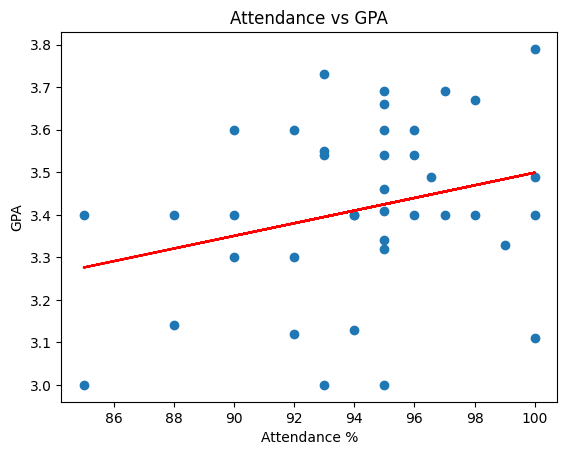

Slope: 0.01623084830049479
Intercept: 1.8897204791256381
41    3.447882
45    3.431651
4     3.399189
14    3.512805
37    3.431651
31    3.382959
6     3.415420
33    3.415420
Name: Your maximum attendance % till last semester, dtype: float64
   Scikit Learn  Manual OLS  Difference
0      3.439632    3.447882    0.008250
1      3.424769    3.431651    0.006882
2      3.395044    3.399189    0.004145
3      3.499081    3.512805    0.013724
4      3.424769    3.431651    0.006882
5      3.380182    3.382959    0.002777
6      3.409907    3.415420    0.005513
7      3.409907    3.415420    0.005513
Loaded Attendance model: {'slope': np.float64(0.014862437825207275), 'intercept': np.float64(2.0128376781643604)}
Predicted GPA (Attendance model): 3.350457082433015


In [84]:
# --------------------------------------------------

# Attendance % -> GPA
X = std[['Your maximum attendance % till last semester']]
y = std['Your GPA of last semester']

# --------------------------------------------------

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# --------------------------------------------------

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# --------------------------------------------------
# Save Model Parameters using Pickle
# --------------------------------------------------
import pickle

attendance_model_params = {
    "slope": model.coef_[0],
    "intercept": model.intercept_
}

with open("attendance_model.pkl", "wb") as f:
    pickle.dump(attendance_model_params, f)

print("Attendance model saved successfully")

# --------------------------------------------------

# Slope and Intercept
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

# --------------------------------------------------

# Predictions
y_pred = model.predict(X_test)
print(y_pred)

# --------------------------------------------------

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -----------------------------
# R² Score
# -----------------------------

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

# -----------------------------
# MSE (Mean Squared Error)
# -----------------------------
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# -----------------------------
# RMSE (Root Mean Squared Error)
# -----------------------------
rmse = mse ** 0.5
print("RMSE:", rmse)

# -----------------------------
# RSE (Residual Standard Error)
# -----------------------------
import numpy as np

n = len(y_test)          # number of test samples
p = 1                    # simple linear regression

rse = np.sqrt(mse * (n / (n - p - 1)))
print("RSE:", rse)

# --------------------------------------------------

# Plot
plt.scatter(
    X,
    y
)

plt.plot(
    X,
    model.predict(X),
    color='red'
)

plt.xlabel('Attendance %')
plt.ylabel('GPA')
plt.title('Attendance vs GPA')
plt.show()

# --------------------------------------------------

# Manual OLS

x = std['Your maximum attendance % till last semester']
y = std['Your GPA of last semester']
n = len(std)

sum_x = x.sum()
sum_y = y.sum()
sum_xy = (x * y).sum()
sum_x2 = (x ** 2).sum()

m = ((n * sum_xy) - (sum_x * sum_y)) / \
    ((n * sum_x2) - (sum_x ** 2))

c = (sum_y - (m * sum_x)) / n

print("Slope:", m)
print("Intercept:", c)

# --------------------------------------------------

# Manual Prediction
manual_pred = m * X_test.iloc[:,0] + c
print(manual_pred)

# --------------------------------------------------

# Comparison
comparison = pd.DataFrame({
    'Scikit Learn': y_pred,
    'Manual OLS': manual_pred.values
})

comparison['Difference'] = abs(
    comparison['Scikit Learn']-comparison['Manual OLS']
)

print(comparison)

# --------------------------------------------------

# Load Pickle File
import pickle

with open("attendance_model.pkl", "rb") as f:
    loaded_attendance = pickle.load(f)

print("Loaded Attendance model:", loaded_attendance)

# --------------------------------------------------

# Predict using Loaded Parameters
attendance_value = 90  # example input

attendance_prediction = (
    loaded_attendance["slope"] * attendance_value +
    loaded_attendance["intercept"]
)

print("Predicted GPA (Attendance model):", attendance_prediction)

## Conclusion
- Performed data preprocessing by handling missing values, duplicates, and converting data to numeric format.
- Built Simple Linear Regression models using Scikit-learn for CIA → GPA and Attendance → GPA.
- Implemented manual OLS method to compute slope and intercept mathematically.
- Verified that Scikit-learn and OLS results are nearly identical.
- Evaluated model performance using R², MSE, RMSE, and RSE.
- Observed a linear relationship between academic factors (CIA/Attendance) and GPA.
- Saved and loaded model parameters using Pickle for reuse without retraining.
- Demonstrated model persistence and prediction using saved parameters.